In [1]:
import sys
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt


SEED = 42
random.seed(SEED)
np.random.seed(SEED)


PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

from utils.hospital_env import HospitalEnv

In [2]:
data = pd.read_csv("../data/synthetic_hospital_data.csv")


In [3]:
STATE_DIM = 4
state_dim=STATE_DIM
ACTIONS = [0, 1]

Episode 1: Total Reward = -1437
Episode 2: Total Reward = -1456
Episode 3: Total Reward = -1354
Episode 4: Total Reward = -1157
Episode 5: Total Reward = -1421
Episode 6: Total Reward = -1357
Episode 7: Total Reward = -1699
Episode 8: Total Reward = -1361
Episode 9: Total Reward = -1155
Episode 10: Total Reward = -1381
Episode 11: Total Reward = -1086
Episode 12: Total Reward = -1154
Episode 13: Total Reward = -1043
Episode 14: Total Reward = -1186
Episode 15: Total Reward = -1030
Episode 16: Total Reward = -813
Episode 17: Total Reward = -936
Episode 18: Total Reward = -970
Episode 19: Total Reward = -661
Episode 20: Total Reward = -827
Episode 21: Total Reward = -819
Episode 22: Total Reward = -486
Episode 23: Total Reward = -1039
Episode 24: Total Reward = -806
Episode 25: Total Reward = -719
Episode 26: Total Reward = -665
Episode 27: Total Reward = -628
Episode 28: Total Reward = -617
Episode 29: Total Reward = -707
Episode 30: Total Reward = -892
Episode 31: Total Reward = -420
E

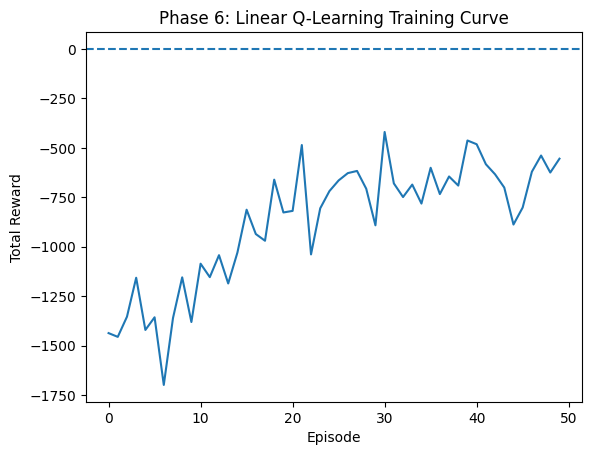

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils.hospital_env import HospitalEnv

data = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "synthetic_hospital_data.csv"))

# ------------------------------------
# State & Action Setup
# ------------------------------------
STATE_DIM = 5
ACTIONS = [0, 1]

def normalize_state(state):
    arrival, slot, priority, no_show, icu_ratio = state
    return np.array([
        arrival / 480.0,
        slot / 480.0,
        priority / 2.0,
        no_show,
        icu_ratio
    ], dtype=np.float32)

# Linear weights
weights = {
    0: np.zeros(STATE_DIM),
    1: np.zeros(STATE_DIM)
}

def Q_value(state, action):
    return np.dot(weights[action], state)

# ------------------------------------
# Hyperparameters
# ------------------------------------
alpha = 0.005
gamma = 0.9
epsilon = 0.2
episodes = 50

episode_rewards = []

# ------------------------------------
# Training Loop
# ------------------------------------
for ep in range(episodes):

    env = HospitalEnv(data)
    state = normalize_state(env.reset())
    done = False
    total_reward = 0

    while not done:

        # ε-greedy
        if np.random.rand() < epsilon:
            action = np.random.choice(ACTIONS)
        else:
            q_vals = [Q_value(state, a) for a in ACTIONS]
            action = ACTIONS[np.argmax(q_vals)]

        next_state, reward, done = env.step(action)
        total_reward += reward

        if not done:
            next_state_norm = normalize_state(next_state)
            target = reward + gamma * max(
                Q_value(next_state_norm, a) for a in ACTIONS
            )
        else:
            target = reward

        prediction = Q_value(state, action)
        error = target - prediction

        # Gradient descent update
        weights[action] += alpha * error * state

        if not done:
            state = next_state_norm

    episode_rewards.append(total_reward)
    print(f"Episode {ep+1}: Total Reward = {total_reward}")

print("\nTraining completed.")

# ------------------------------------
# Plot Learning Curve
# ------------------------------------
plt.figure()
plt.plot(episode_rewards)
plt.axhline(0, linestyle="--")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Phase 6: Linear Q-Learning Training Curve")
plt.show()
